# TI3145TU Midterm Assignment 
## Football Players Wages

We hope you enjoy this assignment, good luck!

Student names: XXX

Student numbers: XXX

### Imports

In [1]:
import numpy as np
import pandas as pd

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

### Load data

In [2]:
# These are your training samples along with their labels
data = pd.read_csv('football_wages.csv')
print("features", data.columns)
data.info()


features Index(['age', 'height_cm', 'weight_kg', 'nationality_name', 'overall',
       'potential', 'attacking_crossing', 'attacking_finishing',
       'attacking_heading_accuracy', 'attacking_short_passing',
       'attacking_volleys', 'skill_dribbling', 'skill_curve',
       'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control',
       'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
       'movement_reactions', 'movement_balance', 'defending_standing_tackle',
       'defending_sliding_tackle', 'goalkeeping_diving',
       'goalkeeping_handling', 'goalkeeping_kicking',
       'goalkeeping_positioning', 'goalkeeping_reflexes', 'log_wages'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         5000 non-null   float64
 1   height_cm     

In [3]:
data.head()

,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,...,movement_reactions,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,log_wages
0,27.0,183.0,76.0,b'Korea Republic',57.0,58.0,54.0,30.0,55.0,53.0,...,60.0,67.0,63.0,58.0,9.0,13.0,8.0,11.0,10.0,3.000000
1,21.0,182.0,70.0,b'France',61.0,72.0,58.0,63.0,46.0,62.0,...,47.0,65.0,31.0,33.0,9.0,11.0,9.0,12.0,11.0,3.000000
2,35.0,182.0,75.0,b'Korea Republic',68.0,68.0,62.0,68.0,68.0,70.0,...,61.0,69.0,36.0,40.0,8.0,12.0,7.0,12.0,6.0,3.301030
3,29.0,169.0,70.0,b'Paraguay',67.0,67.0,62.0,55.0,50.0,71.0,...,59.0,84.0,40.0,55.0,6.0,10.0,11.0,15.0,9.0,2.698970
4,30.0,176.0,74.0,b'Austria',65.0,65.0,63.0,49.0,53.0,63.0,...,58.0,75.0,65.0,64.0,12.0,15.0,10.0,8.0,10.0,3.477121


In [6]:
# You need to extract the features and the regression target. The regression target is 'log_wages'. 
regression_target_Y = data["log_wages"]
features_X = data.drop(["log_wages"], axis=1)

numerical_features_X = features_X.select_dtypes(include=['number']).columns
categorical_features_X = features_X.select_dtypes(include=['object']).columns

# https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html#
# A1) Basic Pipeline: (standardization of data)
numeric_transformer = Pipeline([('scaler', RobustScaler())])
# categorical_transformer = Pipeline([('one-hot', OneHotEncoder(handle_unknown="ignore"))])
categorical_transformer = Pipeline([('ordinal', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
                                    ('minmax', MinMaxScaler(feature_range=(-1, 1)))])
preprocesser_ct = ColumnTransformer(transformers=[
    ('numerical', numeric_transformer, numerical_features_X),
    ('categorical', categorical_transformer, categorical_features_X)
])

X_transformed = preprocesser_ct.fit_transform(features_X)

In [7]:
from sklearn.model_selection import cross_val_score

## Part B

### 4. Simple Baseline
A simple baseline that does not use any knowledge about the player could be the mean of the salary.

We will make use of the Dummy Classifier with the mean as the "best guess".

In [16]:
from sklearn.dummy import DummyRegressor

In [22]:
# Use dummy regression to mean as the baseline, and use it to compute the MAE.
dummy_regressor = DummyRegressor(strategy='mean')

# Run the pipeline using the Dummy classifier.
regressor_dummy = DummyRegressor()

clf_dummy = Pipeline(
    steps=[("preprocessor", preprocesser_ct),
            ("regressor", regressor_dummy)]
)

# Leave-One-Out crossvalidation
# Score: MAE : ‘neg_mean_absolute_error’
# https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names

K = features_X.shape[0]

dummy_negative_mae = cross_val_score(clf_dummy, features_X, regression_target_Y, cv=K, scoring='neg_mean_absolute_error')
dummy_mae = [-x for x in dummy_negative_mae]
dummy_mae_over_cv = sum(dummy_mae) / len(dummy_mae)

print(f'Dummy MAE over {K} folds is: {dummy_mae_over_cv:.3f}')

Dummy MAE over 5000 folds is: 0.492


### 5. KNN and SGD Regressors

We train the KNN and SGD Regressors using their default parameters.
To estimate their performance fairly, we will use Leave-One-Out crossvalidation (i.e. use all but one datapoint for training, then use one for estimation, repeat over all datapoints, and combine scores to an average score).

This should give us an accurate estimate of the generalisation error of the classifiers. To speed up, we can reduce to smaller K-fold crossvalidation when doing Grid Search.

In [ ]:
# Evaluate

regressor_sgd = SGDRegressor()
regressor_knn = KNeighborsRegressor()

# Pipeline 1

clf_sgd = Pipeline(
    steps=[("preprocessor", preprocesser_ct),
            ("regressor", regressor_sgd)]
)

clf_knn = Pipeline(
    steps=[("preprocessor", preprocesser_ct),
            ("regressor", regressor_knn)]
)

# Leave-One-Out crossvalidation
# Score: MAE : ‘neg_mean_absolute_error’
# https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names

K = features_X.shape[0]

sgd_negative_mae = cross_val_score(clf_sgd, features_X, regression_target_Y, cv=K, scoring='neg_mean_absolute_error')
sgd_mae = [-x for x in sgd_negative_mae]
sgd_mae_over_cv = sum(sgd_mae) / len(sgd_mae)

knn_negative_mae = cross_val_score(clf_knn, features_X, regression_target_Y, cv=K, scoring='neg_mean_absolute_error')
knn_mae = [-x for x in knn_negative_mae]
knn_mae_over_cv = sum(knn_mae) / len(knn_mae)

print(f'SGD MAE over {K} folds is: {sgd_mae_over_cv:.3f}')
print(f'KNN MAE over {K} folds is: {knn_mae_over_cv:.3f}')


SGD MAE over 5000 folds is: 0.278
KNN MAE over 5000 folds is: 0.286


Compare performance of the dummy classifier and the two other classifiers using the pipeline

<BarContainer object of 3 artists>

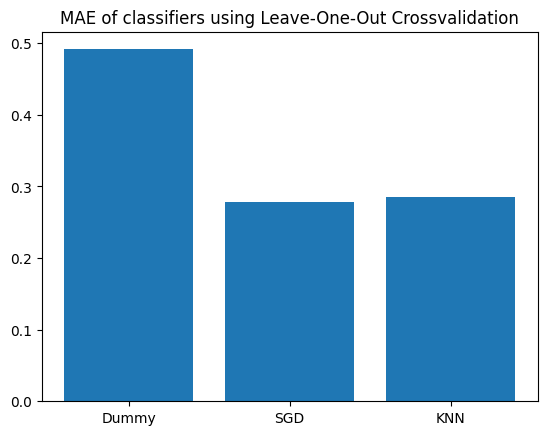

In [28]:
performances_pipeline1 = [
    ('Dummy', dummy_mae_over_cv),
    ('SGD', sgd_mae_over_cv),
    ('KNN', knn_mae_over_cv)
]

plt.title('MAE of classifiers using Leave-One-Out Crossvalidation')
plt.bar([x[0] for x in performances_pipeline1], [x[1] for x in performances_pipeline1])

Pipeline 1 - SGD MAE: `0.278`

Pipeline 2 - KNN MAE: `0.286`

We will use it as the estimation for the autograder.

### 6. Compare pipelines

TODO: compare the two pipelines

### Autograder 

In the autograder you will need to provide two things: 1) estimate of the MAE of your model on unseen data, 2) the predictions on the autograder data. For the autograder data we only provide the features and not the regression targets. Thus, you cannot compute the MAE on this data yourself - you need to estimate that with the data provided above. 

In [6]:
data_autograder = pd.read_csv('football_autograder.csv')
data_autograder.head()


,age,height_cm,weight_kg,nationality_name,overall,potential,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,...,movement_agility,movement_reactions,movement_balance,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,27.0,190.0,78.0,b'England',70.0,71.0,52.0,42.0,75.0,60.0,...,57.0,67.0,61.0,72.0,68.0,15.0,8.0,12.0,13.0,15.0
1,19.0,183.0,76.0,b'Republic of Ireland',59.0,77.0,45.0,20.0,53.0,60.0,...,66.0,55.0,69.0,59.0,57.0,8.0,11.0,10.0,6.0,11.0
2,20.0,172.0,67.0,b'China PR',48.0,53.0,40.0,34.0,38.0,52.0,...,57.0,56.0,70.0,35.0,43.0,12.0,6.0,9.0,7.0,12.0
3,28.0,170.0,65.0,b'Brazil',76.0,76.0,73.0,76.0,52.0,72.0,...,89.0,70.0,88.0,50.0,48.0,12.0,7.0,12.0,10.0,7.0
4,28.0,186.0,74.0,b'England',65.0,67.0,18.0,19.0,15.0,25.0,...,32.0,57.0,57.0,14.0,17.0,66.0,64.0,66.0,63.0,68.0


In [7]:
# TODO Replace this with your own estimate of the MAE of your best model
estimate_MAE_on_new_data = np.array([1.0])

# TODO Replace this with the predictions of your best model
# via e.g. prediction = model.predict(data_autograder)
# your predictions here should again be the $log_{10}(wage)$ of the football player, just as in the provided data. 
predictions_autograder_data = np.array([-1] * 14178)

# Upload this file to the Vocareum autograder:
result = np.append(estimate_MAE_on_new_data, predictions_autograder_data)
pd.DataFrame(result).to_csv("autograder_submission.txt", index=False, header=False)